In [4]:
!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

In [5]:
df = pd.read_excel("Online Retail.xlsx")


In [6]:
df = df.dropna(subset=["CustomerID"])

In [7]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [8]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [9]:
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

In [10]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print("Rows after cleaning:", len(df))

Rows after cleaning: 397884


In [11]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

print(rfm.describe())
rfm.head()

         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [12]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

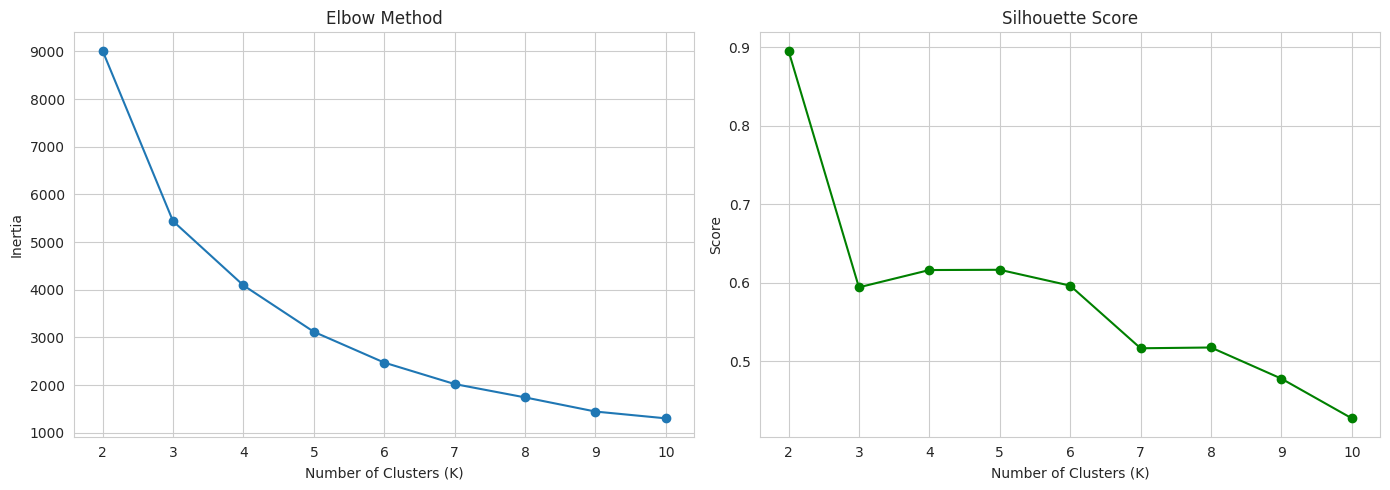

In [13]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), silhouette_scores, marker="o", color="green")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

In [14]:
OPTIMAL_K = 4  # <-- update this based on step 6's plots

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [15]:
# %% [8] Interpret Clusters
cluster_summary = rfm.groupby("Cluster").agg(
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    CustomerCount=("CustomerID", "count")
).round(1)

cluster_summary["RevenueShare%"] = (
    rfm.groupby("Cluster")["Monetary"].sum() / rfm["Monetary"].sum() * 100
).round(1)

print(cluster_summary)

         Recency  Frequency  Monetary  CustomerCount  RevenueShare%
Cluster                                                            
0           43.7        3.7    1359.0           3054           46.6
1          248.1        1.6     480.6           1067            5.8
2            7.4       82.5  127338.3             13           18.6
3           15.5       22.3   12709.1            204           29.1


In [20]:
cluster_summary["CustomerShare%"] = (
    cluster_summary["CustomerCount"]
    / cluster_summary["CustomerCount"].sum() * 100
).round(1)

print(cluster_summary)

         Recency  Frequency  Monetary  CustomerCount  RevenueShare%  \
Cluster                                                               
0           43.7        3.7    1359.0           3054           46.6   
1          248.1        1.6     480.6           1067            5.8   
2            7.4       82.5  127338.3             13           18.6   
3           15.5       22.3   12709.1            204           29.1   

         CustomerShare%  
Cluster                  
0                  70.4  
1                  24.6  
2                   0.3  
3                   4.7  


In [16]:
segment_map = {
    0: "Core/Regular",
    1: "At Risk/Lapsed",
    2: "VIP/Whales",
    3: "Loyal/High-Value"
}

rfm["Segment"] = rfm["Cluster"].map(segment_map)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,Loyal/High-Value
1,12347.0,2,7,4310.00,0,Core/Regular
2,12348.0,75,4,1797.24,0,Core/Regular
3,12349.0,19,1,1757.55,0,Core/Regular
4,12350.0,310,1,334.40,1,At Risk/Lapsed


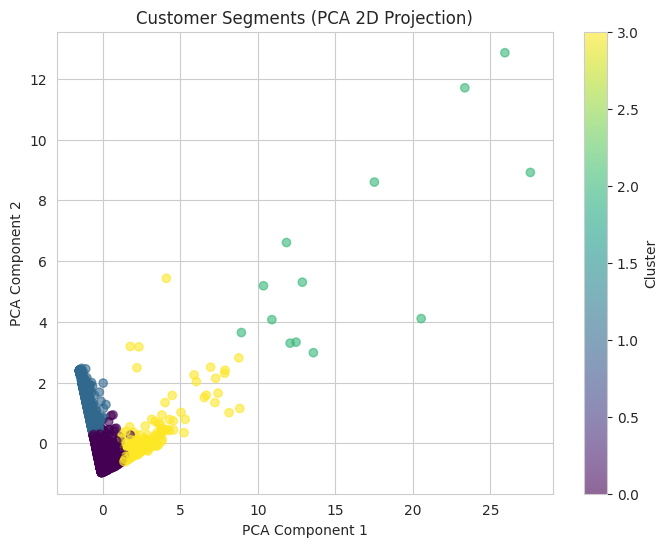

In [17]:
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    rfm_pca[:, 0], rfm_pca[:, 1],
    c=rfm["Cluster"], cmap="viridis", alpha=0.6
)
plt.title("Customer Segments (PCA 2D Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

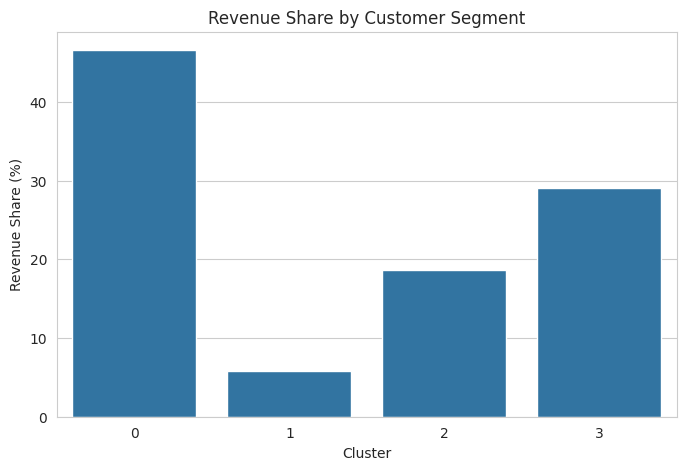

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_summary.index, y=cluster_summary["RevenueShare%"])
plt.title("Revenue Share by Customer Segment")
plt.xlabel("Cluster")
plt.ylabel("Revenue Share (%)")
plt.show()

In [21]:
rfm.to_csv("customer_segments.csv", index=False)
print("Saved customer_segments.csv — import this into Power BI to build the dashboard.")
segment_summary = rfm.groupby("Segment").agg(
    CustomerCount=("CustomerID", "count"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean"),
    TotalRevenue=("Monetary", "sum")
).reset_index()

segment_summary["CustomerShare%"] = (
    segment_summary["CustomerCount"]
    / segment_summary["CustomerCount"].sum() * 100
)

segment_summary["RevenueShare%"] = (
    segment_summary["TotalRevenue"]
    / segment_summary["TotalRevenue"].sum() * 100
)

segment_summary = segment_summary.round(1)

segment_summary.to_csv(
    "segment_summary.csv",
    index=False
)

segment_summary



Saved customer_segments.csv — import this into Power BI to build the dashboard.


,Segment,CustomerCount,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue,CustomerShare%,RevenueShare%
0,At Risk/Lapsed,1067,248.1,1.6,480.6,512818.9,24.6,5.8
1,Core/Regular,3054,43.7,3.7,1359.0,4150536.5,70.4,46.6
2,Loyal/High-Value,204,15.5,22.3,12709.1,2592654.5,4.7,29.1
3,VIP/Whales,13,7.4,82.5,127338.3,1655398.1,0.3,18.6


In [22]:
recommendations = {
    "VIP/Whales":
        "Prioritize retention through personalized service, exclusive benefits, and premium loyalty rewards.",

    "Loyal/High-Value":
        "Strengthen loyalty through rewards, cross-selling, upselling, and personalized product recommendations.",

    "Core/Regular":
        "Increase purchase frequency and move customers toward the Loyal segment through targeted offers and recommendations.",

    "At Risk/Lapsed":
        "Run win-back campaigns using personalized discounts, reminders, and re-engagement offers."
}

for segment, recommendation in recommendations.items():
    print(f"{segment}: {recommendation}")

VIP/Whales: Prioritize retention through personalized service, exclusive benefits, and premium loyalty rewards.
Loyal/High-Value: Strengthen loyalty through rewards, cross-selling, upselling, and personalized product recommendations.
Core/Regular: Increase purchase frequency and move customers toward the Loyal segment through targeted offers and recommendations.
At Risk/Lapsed: Run win-back campaigns using personalized discounts, reminders, and re-engagement offers.
